<a href="https://colab.research.google.com/github/Manasa23BEIS123/AIML-12-Week-Program/blob/feat%2Faiml-W3-Manasa/W3D2_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# W3D2: Linear Regression, Ridge & Lasso

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load California Housing dataset

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("Dataset loaded successfully")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully
Shape: (20640, 9)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Separate features and target

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features shape: (20640, 8)
Target shape: (20640,)

Feature columns:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target:
MedHouseVal


In [4]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (16512, 8)
Testing features: (4128, 8)
Training target: (16512,)
Testing target: (4128,)


In [5]:
# Train Linear Regression model

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Print intercept
print("Intercept:", linear_model.intercept_)

# Print coefficients
print("\nCoefficients:")
for feature, coefficient in zip(X.columns, linear_model.coef_):
    print(f"{feature}: {coefficient:.6f}")

Intercept: -37.02327770606409

Coefficients:
MedInc: 0.448675
HouseAge: 0.009724
AveRooms: -0.123323
AveBedrms: 0.783145
Population: -0.000002
AveOccup: -0.003526
Latitude: -0.419792
Longitude: -0.433708


In [6]:
# Make predictions

y_pred = linear_model.predict(X_test)

# Calculate evaluation metrics

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print("-----------------------------")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
-----------------------------
MSE  : 0.5559
RMSE : 0.7456
MAE  : 0.5332
R²   : 0.5758


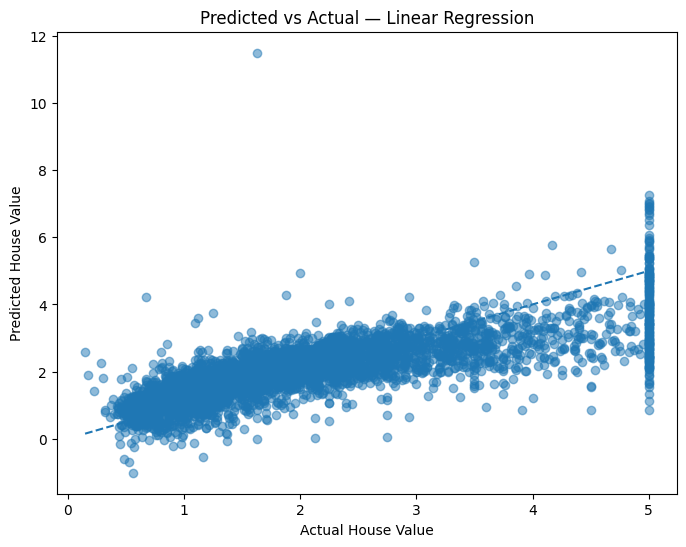

In [7]:
# Predicted vs Actual plot

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Predicted vs Actual — Linear Regression")
plt.show()

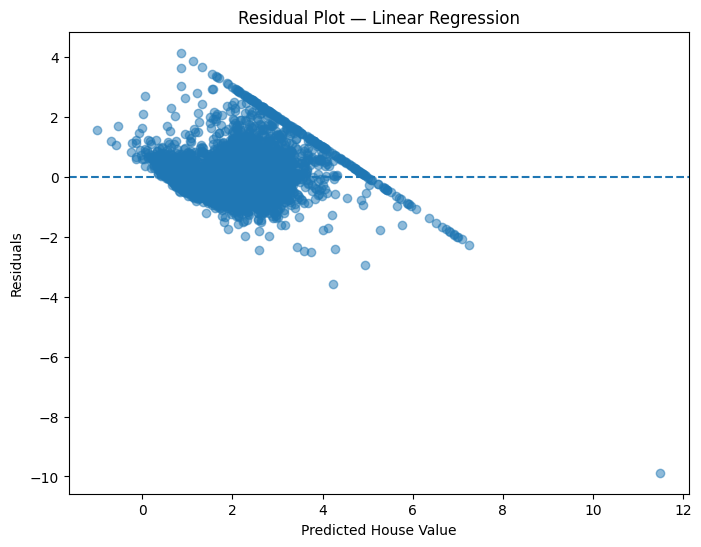

In [8]:
# Calculate residuals

residuals = y_test - y_pred

# Residual plot

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residuals")
plt.title("Residual Plot — Linear Regression")
plt.show()

In [9]:
# Train Ridge and Lasso models

ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.001)

ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

print("Ridge and Lasso models trained successfully")

Ridge and Lasso models trained successfully


In [10]:
# Evaluate Linear Regression, Ridge, and Lasso

models = {
    "Linear Regression": linear_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model
}

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    })

results_df = pd.DataFrame(results)

print("Model Comparison:")
display(results_df.round(4))

Model Comparison:


,Model,MSE,RMSE,MAE,R²
0,Linear Regression,0.5559,0.7456,0.5332,0.5758
1,Ridge,0.5558,0.7455,0.5332,0.5759
2,Lasso,0.5539,0.7442,0.5333,0.5773


In [11]:
# Compare model coefficients

coefficients_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear Regression": linear_model.coef_,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_
})

display(coefficients_df.round(6))



,Feature,Linear Regression,Ridge,Lasso
0,MedInc,0.448675,0.448511,0.444698
1,HouseAge,0.009724,0.009726,0.009783
2,AveRooms,-0.123323,-0.123014,-0.115737
3,AveBedrms,0.783145,0.781417,0.741172
4,Population,-0.000002,-0.000002,-0.000002
5,AveOccup,-0.003526,-0.003526,-0.003510
6,Latitude,-0.419792,-0.419787,-0.418522
7,Longitude,-0.433708,-0.433681,-0.431828


## W3D2: Linear Regression, Ridge & Lasso

### Objective

Build and evaluate regression models for predicting house prices using the California Housing dataset.

### Models Used

* Linear Regression
* Ridge Regression
* Lasso Regression

### Evaluation Metrics

The models were evaluated using:

* Mean Squared Error (MSE)
* Root Mean Squared Error (RMSE)
* Mean Absolute Error (MAE)
* R² Score

### Visualizations

* Predicted vs Actual values
* Residual plot

### Comparison

Linear Regression, Ridge, and Lasso were compared using a results table based on MSE, RMSE, MAE, and R².

### Conclusion

Regularization techniques such as Ridge and Lasso help control model coefficients and can reduce the risk of overfitting. The evaluation metrics provide a quantitative comparison of the three regression approaches.
